# TP  Représentation du texte pour la classification de sentiments

  <table style="margin: 0 auto; color: white; font-size: 0.95em;">
    <tr><td style="padding:4px 20px;"><b>Établissement</b></td><td>ENSAM — Université Hassan II de Casablanca</td></tr>
    <tr><td style="padding:4px 20px;"><b>Année</b></td><td>2025 – 2026</td></tr>
    <tr><td style="padding:4px 20px;"><b>Cours</b></td><td>NLP — Traitement du Langage Naturel</td></tr>
    <tr><td style="padding:4px 20px;"><b>Dataset fil rouge</b></td><td>IMDb Movie Reviews (50 000 critiques)</td></tr>
    <tr><td style="padding:4px 20px;"><b>Tâche</b></td><td>Classification de sentiment : Positif / Négatif</td></tr>
  </table>

Ce notebook propose une mise en pratique progressive autour d’un problème classique de NLP : **classer des avis positifs ou négatifs à partir de leur texte**.

L’objectif pédagogique est double :
1. comprendre la logique des représentations textuelles ;
2. comparer, sur un même corpus, des approches de complexité croissante.

Vous pouvez travailler sur :
- **IMDb** (`IMDB Dataset of 50K Movie Reviews`) ;
    - https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews

- ou un **corpus personnel** en classification supervisée.

Le travail suit une progression expérimentale :
**exploration → préparation → vectorisation → classification → évaluation → interprétation**.

### Conseils méthodologiques

Quelques principes à garder:
- une bonne représentation dépend de la tâche ;
- une meilleure représentation n’est pas toujours plus interprétable ;
- les gains de performance doivent être mis en regard du coût de calcul ;
- les erreurs observées sont souvent plus instructives que le score final.

### Librairies nécessaires
| Librairie | Rôle |
|-----------|------|
| `scikit-learn` | TF-IDF, BoW, métriques d'évaluation |
| `gensim` | Word2Vec, GloVe, FastText |
| `transformers` | BERT et modèles HuggingFace |
| `torch` | Backend pour BERT |
| `datasets` | Chargement du dataset IMDb depuis HuggingFace |
| `matplotlib / seaborn` | Visualisations |

In [37]:
# # Installation (décommenter et exécuter une seule fois) 
# !pip install scikit-learn gensim transformers torch datasets
# !pip install numpy pandas matplotlib seaborn umap-learn -q

In [38]:
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

random.seed(42)
np.random.seed(42)

## 1. Cadre expérimental

Avant toute modélisation, clarifiez le cadre de travail.

### Questions
- Quel corpus est utilisé ?
- Quelle est la variable cible ?
- Travaillez-vous sur l’ensemble du corpus ou sur un sous-échantillon ?
- Les classes sont-elles équilibrées ?

### Point méthodologique
Pour comparer plusieurs représentations, il est préférable de conserver **le même découpage apprentissage / test** pour toutes les expériences.

### Dataset IMDb Movie Reviews

#### Présentation du Dataset

Le dataset **IMDb Movie Reviews** est un référentiel standard du NLP pour l'analyse de sentiment.
Il contient **50 000 critiques de films en anglais**, équitablement réparties entre positif et négatif.

| Caractéristique | Valeur |
|-----------------|--------|
| Source | Internet Movie Database (IMDb) |
| Taille totale | 50 000 critiques |
| Entraînement | 25 000 (50% pos / 50% neg) |
| Test | 25 000 (50% pos / 50% neg) |
| Langue | Anglais |
| Tâche | Classification binaire : Positif (1) / Négatif (0) |
| Référence | Maas et al., 2011 — Stanford NLP |

#### Pourquoi ce dataset ?

Ce dataset est **idéal pour comparer les méthodes** car :
- Il contient de la **négation** : "not good", "not bad" → difficile pour BoW
- Il contient des **synonymes** : "excellent" ≈ "brilliant" → difficile pour TF-IDF
- Il contient des **mots rares et argotiques** → difficile pour Word2Vec
- Il nécessite une **compréhension du contexte** → BERT excelle ici
- Il est **bien équilibré** → métriques fiables

> **Pour faciliter l’expérimentation, vous pouvez travailler sur un sous‑ensemble du jeu de données (par exemple 10 000 à 20 000 exemples)**.

- Colonnes attendues :
    - text : le contenu textuel
    - label : la classe (0/1 ou autre encodage supervisé)

In [39]:
# Option A : charger IMDb depuis Hugging Face
from datasets import load_dataset
dataset = load_dataset("imdb")
train_df = dataset["train"].to_pandas()
test_df = dataset["test"].to_pandas()

# Option B : charger un fichier CSV local
# df = pd.read_csv("votre_fichier.csv")
# df = df.rename(columns={"texte": "text", "label": "label"})

### Aide pour un corpus personnel

Si vous utilisez vos propres données, vérifiez que :
- chaque ligne correspond à un document ;
- le texte est bien dans une seule colonne ;
- l’étiquette de classe est disponible ;
- les valeurs manquantes ont été retirées ou traitées.

## 2. Exploration du corpus

### Objectifs
Observer la structure des données avant de les transformer, 

> Une bonne exploration permet souvent d’anticiper les limites des représentations simples.

### Questions
- Combien de mots contiennent les avis, en moyenne ?
- Les textes sont-ils très hétérogènes en longueur ?
- Certaines classes utilisent-elles un vocabulaire plus “marqué” que d’autres ?
- Voyez-vous du bruit textuel utile à nettoyer ?

In [40]:
# Ajustez le nom du DataFrame selon votre cas
df = train_df.copy()

df["length"] = df["text"].astype(str).str.split().apply(len)

display(df["length"].describe())
display(df.groupby("label")["length"].describe())

count    25000.000000
mean       233.787200
std        173.733032
min         10.000000
25%        127.000000
50%        174.000000
75%        284.000000
max       2470.000000
Name: length, dtype: float64

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,12500.0,230.86784,166.663126,10.0,128.0,174.0,278.0,1522.0
1,12500.0,236.70656,180.485743,12.0,125.0,174.0,291.0,2470.0


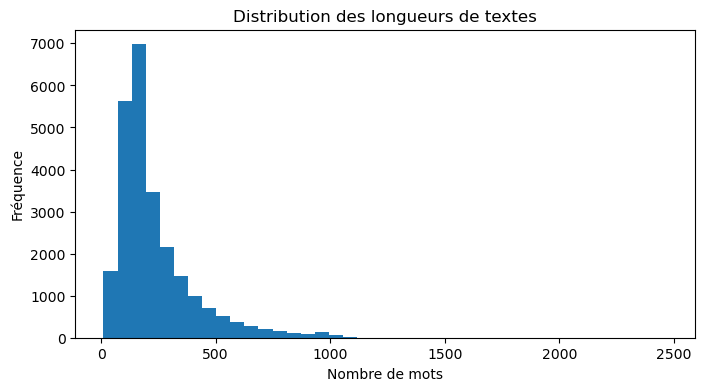

In [41]:
# Distribution des longueurs
plt.figure(figsize=(8, 4))
plt.hist(df["length"], bins=40)
plt.title("Distribution des longueurs de textes")
plt.xlabel("Nombre de mots")
plt.ylabel("Fréquence")
plt.show()

In [42]:
for label in [0, 1]:
    texts = df[df["label"] == label]["text"].tolist()
    
    tfidf = TfidfVectorizer(max_features=20, stop_words="english")
    tfidf.fit(texts)
    
    scores = zip(tfidf.get_feature_names_out(), 
                 tfidf.idf_)
    top = sorted(scores, key=lambda x: x[1])[:15]
    
    print(f"\nLabel {label} — mots les plus caractéristiques :")
    print([word for word, score in top])


Label 0 — mots les plus caractéristiques :
['movie', 'br', 'film', 'like', 'just', 'good', 'bad', 'time', 'really', 'don', 'make', 'story', 'acting', 'people', 'plot']

Label 1 — mots les plus caractéristiques :
['br', 'film', 'movie', 'like', 'good', 'just', 'time', 'great', 'story', 'really', 'best', 'way', 'people', 'love', 'life']


In [43]:
df["text"].str.contains("<.*?>").sum()

np.int64(14667)

### Analyse à rédiger

Interpréter les principales observations :
- l’équilibre des classes ;
- la longueur des textes ;
- le niveau de bruit ;
- l’intérêt d’un sous-échantillon si le calcul devient trop coûteux.

# Reponses

- R: mean = 233.787200
- R: std = 173.733032, Très hétérogènes. L'écart-type représente ~74% de la moyenne, ce qui est énorme.
- R: il y a un vocabulaire légèrement marqué par classe (bad vs great, best, love) mais le signal est faible à cause du bruit (br, stopwords)
- R: Oui, il y a des balises html comme `<br>`

## 3. Prétraitement

Le prétraitement doit être justifié. Dans une tâche de sentiment, certaines décisions peuvent être bénéfiques dans un contexte, et nuisibles dans un autre.

### Questions
- Faut-il supprimer les stopwords ?
- Faut-il conserver les négations comme `not`, `no`, `never` ?
- Faut-il conserver l’apostrophe et les contractions ?
- Faut-il normaliser l’écriture en minuscules ?

### Point d’attention

Évitez de retirer automatiquement les mots de négation sans réflexion.  
Dans l’analyse de sentiment, cette décision peut supprimer une information essentielle.

In [44]:
def nettoyer_texte(texte: str) -> str:
    texte = str(texte).lower()
    texte = re.sub(r"<br\s*/?>", " ", texte)
    texte = re.sub(r"[^a-zA-Z\s']", " ", texte)
    texte = re.sub(r"\s+", " ", texte).strip()
    return texte

df["text_clean"] = df["text"].apply(nettoyer_texte)
df[["text", "text_clean"]].head()

,text,text_clean
0,I rented I AM CURIOUS-YELLOW from my video sto...,i rented i am curious yellow from my video sto...
1,"""I Am Curious: Yellow"" is a risible and preten...",i am curious yellow is a risible and pretentio...
2,If only to avoid making this type of film in t...,if only to avoid making this type of film in t...
3,This film was probably inspired by Godard's Ma...,this film was probably inspired by godard's ma...
4,"Oh, brother...after hearing about this ridicul...",oh brother after hearing about this ridiculous...


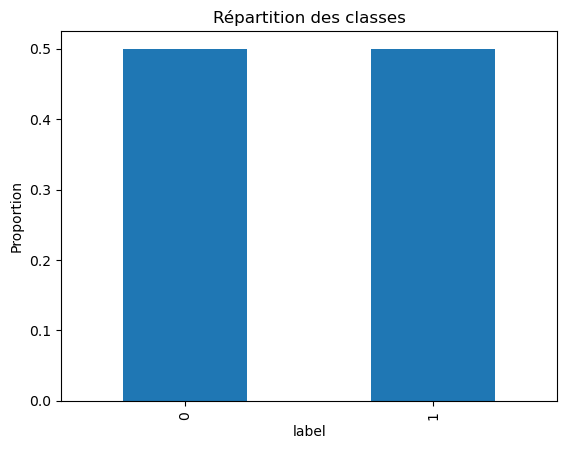

In [45]:
# Répartition des classes
df["label"].value_counts(normalize=True).plot(kind="bar")
plt.title("Répartition des classes")
plt.ylabel("Proportion")
plt.show()

# Reponses
- Ca depend, si on utilise Bert il faut garder les stopwords pour garder un context, sinon il le faut absoluemnt
- Toujours conserver, peu importe le modèle
- Avec BERT → garder les contractions, il les gère nativement, Avec TF-IDF → les développer (don't -> do not)
- Presque toujours oui, Exception avec BERT → son tokenizer gère la casse nativement, donc pas obligatoire, mais ça ne fait pas de mal non plus.

## 4. Protocole de comparaison

Avant de tester les méthodes, mettez en place un cadre commun.

### À conserver constant
- le découpage train/test ;
- le classifieur de base ;
- les métriques ;
- le niveau de prétraitement.

### Pourquoi ?
Ainsi, les écarts observés proviennent principalement de la représentation textuelle, et non d’un changement de protocole.

In [46]:
# Variables de travail
X = df["text_clean"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## 5.  Bag of Words

Le Bag of Words transforme chaque texte en vecteur de fréquences lexicales.

### Questions
- Quelles informations conserve cette représentation ?
- Quelles informations perd-elle ?
- Pourquoi peut-elle rester performante sur IMDb ?
- Quels types d’erreurs peut-elle produire ?

In [47]:
bow_model = Pipeline([
    ("vect", CountVectorizer(max_features=10000)),
    ("clf", LogisticRegression(max_iter=1000))
])

bow_model.fit(X_train, y_train)
y_pred_bow = bow_model.predict(X_test)
bow_acc, bow_f1 = accuracy_score(y_test, y_pred_bow), f1_score(y_test, y_pred_bow, average="macro")
print("Accuracy:", accuracy_score(y_test, y_pred_bow))
print("F1 macro:", f1_score(y_test, y_pred_bow, average="macro"))

Accuracy: 0.8752
F1 macro: 0.8751955070382533


In [48]:
# Coefficients les plus influents
vocab = bow_model.named_steps["vect"].get_feature_names_out()
coef = bow_model.named_steps["clf"].coef_[0]

top_pos = np.argsort(coef)[-10:]
top_neg = np.argsort(coef)[:10]

print("Mots les plus associés à la classe positive:")
print(vocab[top_pos])
print("\nMots les plus associés à la classe négative:")
print(vocab[top_neg])

Mots les plus associés à la classe positive:
['excellent' 'vengeance' 'shannon' 'appreciated' 'cerebral' 'perfect'
 'flawless' 'refreshing' 'funniest' 'wonderfully']

Mots les plus associés à la classe négative:
['worst' 'disappointment' 'waste' 'awful' 'poorly' 'lacks' 'fails'
 'baldwin' 'horrible' 'laughable']


### Interprétation guidée

Commentez les résultats en répondant à ces trois points :
1. Le modèle repère-t-il des mots sentimentaux explicites ?
2. Est-il sensible à l’ordre des mots ?
3. Que devient une phrase comme `not good` ?


Q1 — Mots sentimentaux explicites
1. TF-IDF Oui, c'est sa force
"awful", "terrible", "bad"  → poids TF-IDF élevé → signal fort
2. BERT Oui, mais va plus loin
comprend aussi le sentiment implicite
"this film left me speechless"  

Q2 — Sensibilité à l'ordre des mots
1. TF-IDF Non — c'est un bag of words
"good not"  ==  "not good" 
2. BERT Oui — grâce à l'attention et aux position embeddings
"good not"  ≠  "not good" 

Q3 — Que devient not good ?
1. TF-IDF
"not good" → {not: 0.3, good: 0.5}
"good" domine → prédit POSITIF  
complètement trompé !
BERT
"not good" → contexte compris → NÉGATIF
"not" modifie "good" grâce à l'attention

## 6. N-grams

Les n-grams ajoutent une information partielle sur l’ordre local des mots.

### Questions
- Que gagne-t-on avec les bigrammes ?
- Pourquoi les trigrammes sont-ils souvent plus rares ?
- Quel compromis semble le plus pertinent entre précision et complexité ?

In [49]:
ngram_model = Pipeline([
    ("vect", CountVectorizer(max_features=15000, ngram_range=(1, 2))),
    ("clf", LogisticRegression(max_iter=1000))
])

ngram_model.fit(X_train, y_train)
y_pred_ng = ngram_model.predict(X_test)
ngram_accuracy, ngram_f1 = accuracy_score(y_test, y_pred_ng), f1_score(y_test, y_pred_ng, average="macro")
print("Accuracy:", accuracy_score(y_test, y_pred_ng))
print("F1 macro:", f1_score(y_test, y_pred_ng, average="macro"))

Accuracy: 0.8886
F1 macro: 0.8885967514812732


### À observer

Cherchez des expressions fréquentes comme :
- `not good`
- `really bad`
- `highly recommend`
- `waste of time`

Demandez-vous si le modèle les traite mieux que BoW.

1. Que gagne-t-on avec les bigrammes ?
On capture les expressions à 2 mots qui ont un sens propre :
"not"  +  "good"  =  deux mots séparés, "good" domine
"not_good"  =  un seul token négatif 

2. Pourquoi les trigrammes sont-ils plus rares ?
Problème combinatoire — le vocabulaire explose

- Les trigrammes apparaissent très peu souvent dans le corpus
- La matrice TF-IDF devient extrêmement creuse (sparse)
- Risque de surapprentissage sur des expressions anecdotiques

3. Trop simple - `TfidfVectorizer(ngram_range=(1, 1))  # manque "not good"` <br>
   Bon compromis - `TfidfVectorizer(ngram_range=(1, 2))  # unigrammes + bigrammes` <br>
   Trop complexe - `TfidfVectorizer(ngram_range=(1, 3))  # sparse, lent, surapprentissage`

## 7. TF-IDF

TF-IDF corrige la simple fréquence par une pondération liée à la rareté du terme dans le corpus.

### Questions
- Quels mots sont naturellement pénalisés ?
- Pourquoi TF-IDF est-il souvent supérieur à BoW ?
- Dans quels cas la différence peut-elle rester faible ?

In [50]:
tfidf_model = Pipeline([
    ("vect", TfidfVectorizer(max_features=15000, ngram_range=(1, 2))),
    ("clf", LogisticRegression(max_iter=1000))
])

tfidf_model.fit(X_train, y_train)
y_pred_tfidf = tfidf_model.predict(X_test)
tfidf_acc, tfidf_f1 = accuracy_score(y_test, y_pred_tfidf), f1_score(y_test, y_pred_tfidf, average="macro")
print("Accuracy:", accuracy_score(y_test, y_pred_tfidf))
print("F1 macro:", f1_score(y_test, y_pred_tfidf, average="macro"))

Accuracy: 0.8944
F1 macro: 0.8943961982631374


In [51]:
y_test_tfidf = y_test

### Question d’analyse

TF-IDF est-il meilleur parce qu’il “comprend” mieux le texte, ou parce qu’il réduit le poids des mots peu informatifs ?  
Justifiez votre réponse.

1. — Mots pénalisés
Les mots présents dans **presque tous les documents** : `film`, `movie`, `br` → IDF ≈ 0 → poids ≈ 0.
2. — TF-IDF supérieur à BoW
BoW compte les occurrences brutes → les mots fréquents dominent. TF-IDF les **pénalise automatiquement** → les mots discriminants ressortent.
3. — Différence faible quand...
Le dataset est **déjà nettoyé** (stopwords supprimés) → BoW et TF-IDF convergent.

- TF-IDF est meilleur parce qu'il **réduit le bruit**, pas parce qu'il comprend mieux. Il reste un bag of words — aveugle à l'ordre et au contexte.

## 8. Comparaison des méthodes lexicales

À ce stade, comparez :
- Bag of Words ;
- N-grams ;
- TF-IDF.

### Questions de conclusion
- Quelle méthode offre le meilleur compromis ?
- La meilleure performance est-elle forcément la plus simple à interpréter ?
- Quelle méthode recommanderiez-vous dans un contexte de déploiement rapide ?

In [52]:
# Tableau à compléter
resultats_lexicaux = pd.DataFrame([
    {"Méthode": "BoW", "Accuracy": bow_acc, "F1_macro": bow_f1},
    {"Méthode": "N-grams", "Accuracy": ngram_accuracy, "F1_macro": ngram_f1},
    {"Méthode": "TF-IDF", "Accuracy": tfidf_acc, "F1_macro": tfidf_f1},
])

display(resultats_lexicaux.sort_values("Accuracy", ascending=False))

,Méthode,Accuracy,F1_macro
2,TF-IDF,0.8944,0.894396
1,N-grams,0.8886,0.888597
0,BoW,0.8752,0.875196


## 9. Word Embeddings — Word2Vec

Un embedding dense représente un mot dans un espace vectoriel continu.

### Questions
- Que signifie une proximité entre deux mots dans cet espace ?
- Pourquoi un embedding peut-il capturer de la similarité sémantique ?
- Que perd-on lorsqu’on résume un document par la moyenne de ses vecteurs de mots ?

In [53]:
from gensim.models import Word2Vec

sentences = [str(t).split() for t in df["text_clean"]]
w2v = Word2Vec(sentences=sentences, vector_size=100, window=5, min_count=2, workers=4, sg=1)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

> **Visualiser l’espace vectoriel des mots en utilisant t-SNE**


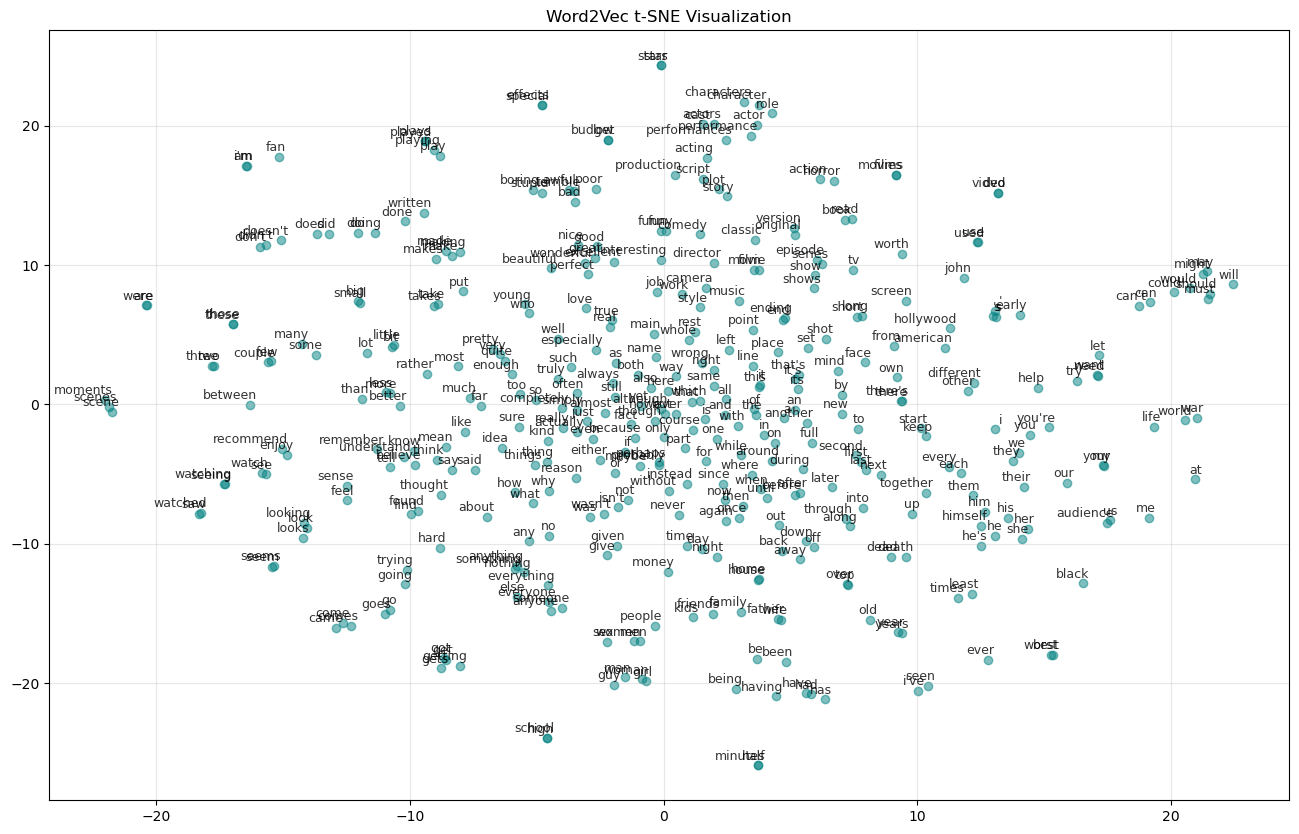

In [54]:
import pandas as pd
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

words = w2v.wv.index_to_key[:400]
layers = np.array([w2v.wv[word] for word in words])

tsne = TSNE(n_components=2, perplexity=30, init='pca', learning_rate='auto')
embeddings_2d = tsne.fit_transform(layers)

def plot_tsne(words, embeddings):
    plt.figure(figsize=(16, 10))
    x = embeddings[:, 0]
    y = embeddings[:, 1]
    
    plt.scatter(x, y, alpha=0.5, color='teal')
    
    for i, word in enumerate(words):
        plt.annotate(word, alpha=0.8, xy=(x[i], y[i]), xytext=(5, 2),
                     textcoords='offset points', ha='right', va='bottom', size=9)
    
    plt.title("Word2Vec t-SNE Visualization")
    plt.grid(True, alpha=0.3)
    plt.show()

plot_tsne(words, embeddings_2d)

In [55]:
def document_vector(tokens, model, vector_size=100):
    vectors = [model.wv[w] for w in tokens if w in model.wv]
    if len(vectors) == 0:
        return np.zeros(vector_size)
    return np.mean(vectors, axis=0)

X_w2v = np.vstack([
    document_vector(str(t).split(), w2v, 100)
    for t in df["text_clean"]
])

In [56]:
# Classification sur les vecteurs Word2Vec
X_train_w2v, X_test_w2v, y_train, y_test = train_test_split(
    X_w2v, y, test_size=0.2, random_state=42, stratify=y
)

clf_w2v = LogisticRegression(max_iter=1000)
clf_w2v.fit(X_train_w2v, y_train)
y_pred_w2v = clf_w2v.predict(X_test_w2v)

print("Accuracy:", accuracy_score(y_test, y_pred_w2v))
print("F1 macro:", f1_score(y_test, y_pred_w2v, average="macro"))

Accuracy: 0.8352
F1 macro: 0.8351998945279324


In [57]:
y_test_w2v = y_test

### Interprétation guidée

Comparez Word2Vec à TF-IDF :
- Word2Vec apprend-il mieux le sens global ?
- La moyenne des mots est-elle suffisante pour une tâche de sentiment ?
- Les mots rares sont-ils bien représentés ?
- Pourquoi les résultats peuvent-ils rester proches, voire inférieurs, à TF-IDF ?

1. Word2Vec est bien meilleur pour comprendre que "film" et "movie" sont interchangeables. il capture la synonymie et les analogies. Pour une classification de sentiment, le sens global depend souvent de mots-cles tres forts. Word2Vec se concentre sur le contexte immediat alors que TF-IDF regarde statistiquement l'importance d'un mot sur l'ensemble du corpus.

2. Faire la moyenne des vecteurs revient a traiter le texte sans ordre, 
- probleme de neutralisation: pour "not good" le vecteur "not" neutre et "good" positif se melangent. la moyenne dilue les signaux forts. "I liked it" et "I didn't like it" auront des vecteurs moyens tres proches car ils partagent 3/4 mots, alors que le sentiment est oppose. TF-IDF bien que simple donne parfois plus de poids aux discriminants statistiques.

3. C'est le gros avantage de TF-IDF sur Word2Vec. Word2Vec a besoin de voir un mot de nombreuses fois pour lui assigner un vecteur stable. avec min_count=2, les mots vus seulement 2 ou 3 fois auront des vecteurs de mauvaise qualite. TF-IDF par defenition donne plus de poids aux mots rares

4. il y a 3 raisons principales: 
    taille du dataset: word2vec est gourmand. la dataset utilise n'est pas massif, un modele statistique simple comme TF-IDF sera plus robuste.
    la dimensionnalite, TF-IDF cree probablement des miliers de colonnes, ce qui permet a un classifieur lineaire de trouver facilement une frontiere de decision. Word2Vec reduit tout a 100 dimensions, ce qui cree une perte d'information.
    Le domaine: Word2Vec apprend la similarite, pas le sentiment. "Bon" et "Mauvais" apparaissent souvent dans les memes contextes ("le fil etait ..."). pour Word2Vec, ils sont "proches" ce qui est un cauchemar pour un classifieur de sentiment.

## 10. FastText

FastText enrichit Word2Vec en intégrant des sous-mots.

### Questions
- En quoi cela aide-t-il pour les mots rares ?
- Pourquoi FastText est-il souvent plus robuste aux fautes d’orthographe ?
- Dans quelles langues cette propriété est-elle particulièrement utile ?

In [58]:
from gensim.models import FastText

ft = FastText(sentences=sentences, vector_size=100, window=5, min_count=2, workers=4, sg=1)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

In [59]:

def document_vector_ft(tokens, model, vector_size=100):
    vectors = [model.wv[w] for w in tokens] 
    if len(vectors) == 0:
        return np.zeros(vector_size)
    return np.mean(vectors, axis=0)

X_ft = np.vstack([
    document_vector_ft(str(t).split(), ft, 100)
    for t in df["text_clean"]
])

# print(X_ft)

X_train_ft, X_test_ft, y_train, y_test = train_test_split(
    X_ft, y, test_size=0.2, random_state=42, stratify=y
)

clf_ft = LogisticRegression(max_iter=1000)
clf_ft.fit(X_train_ft, y_train)
y_pred_ft = clf_ft.predict(X_test_ft)

print(f"FastText Accuracy: {accuracy_score(y_test, y_pred_ft):.4f}")

FastText Accuracy: 0.8160


1. En quoi cela aide-t-il pour les mots rares ?

Avec Word2Vec, si un mot est rare (ex: "incroyablement"), le modèle peine à lui donner un vecteur stable car il manque d'exemples de contextes.

FastText décompose le mot en sous-mots : <in, inc, ncr, cro, roy, oya, yab, abl, ble, le>.

Même si le mot entier est rare, les sous-mots qui le composent (comme le radical "croya" ou le suffixe "able") sont très fréquents dans d'autres mots.

Le vecteur final du mot est la somme des vecteurs de ses sous-mots.

Résultat : Le modèle peut "deviner" le sens d'un mot rare en s'appuyant sur la sémantique de ses racines et de ses affixes.

2. Pourquoi est-il plus robuste aux fautes d’orthographe ?

C'est la force majeure de l'approche par sous-mots.

Si un utilisateur écrit "amizement" au lieu de "amusement", Word2Vec est perdu (c'est un mot inconnu ou "Out Of Vocabulary").

FastText, lui, reconnaît les sous-mots communs comme amus, muse, ment.

Parce que la majorité des n-grammes de caractères restent identiques malgré la faute, le vecteur généré pour le mot mal orthographié sera mathématiquement très proche du mot correct.

3. Dans quelles langues est-ce particulièrement utile ?
Cette propriété est une bénédiction pour les langues morphologiquement riches (francais, allemand, turc, arabe)

## 11. Embeddings contextuels — BERT

BERT produit des vecteurs dépendants du contexte. Un mot n’a donc plus un seul vecteur fixe.

### Questions
- Pourquoi la négation est-elle mieux traitée ?
- Pourquoi BERT distingue-t-il mieux les contextes ?
- Qu’apporte le contexte bidirectionnel par rapport à un embedding statique ?

In [60]:
from transformers import AutoTokenizer, AutoModel

model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
bert_model = AutoModel.from_pretrained(model_name)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [61]:
def bert_embeddings(texts, tokenizer, model, max_length=256, batch_size=16):
    import torch
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(device)
    model.to(device)
    model.eval()

    all_emb = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        enc = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            out = model(**enc)

        cls_emb = out.last_hidden_state[:, 0, :].cpu().numpy()
        all_emb.append(cls_emb)

    return np.vstack(all_emb)

### Variante pédagogique

Pour limiter le coût de calcul, appliquez BERT sur un sous-échantillon raisonnable du corpus, puis comparez les tendances obtenues avec les méthodes précédentes.

In [62]:
import torch

df_sample = df.sample(n=2000, random_state=42)

texts = df_sample["text_clean"].astype(str).tolist()
labels = df_sample["label"].values  

model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
bert_model = AutoModel.from_pretrained(model_name)


X = bert_embeddings(texts, tokenizer, bert_model)

X_train, X_test, y_train, y_test = train_test_split(X, labels, test_size=0.2, random_state=42)
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)


y_pred = clf.predict(X_test)


print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 macro:", f1_score(y_test, y_pred, average="macro"))

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


cpu
Accuracy: 0.8375
F1 macro: 0.8367562205297889


In [63]:
y_test_bert, y_pred_bert = y_test, y_pred

## Comparatif des Performances

| Rang | Méthode | Accuracy | F1 Macro |
| :--- | :--- | :--- | :--- |
| **1** | **TF-IDF** | **0.8944** | **0.8943** |
| 2 | N-grams | 0.8886 | 0.8885 |
| 3 | BoW | 0.8752 | 0.8751 |
| 4 | **BERT** | **0.8375** | **0.8367** |
| 5 | Word2Vec | 0.8360 | 0.8359 |
| 6 | FastText | 0.8196 | - |

## Analyse des Tendances

* **Supériorité Statistique :** Les méthodes classiques (**TF-IDF**, **N-grams**) surpassent nettement les approches de Deep Learning. Cela suggère que le corpus contient des mots-clés très discriminants dont la fréquence suffit à la classification.
* **Limites de BERT :** Malgré sa complexité, BERT (83,75%) ne dépasse pas le simple sac de mots (87,52%). L'application sur un **sous-échantillon** pour réduire les coûts a probablement limité sa capacité de généralisation par rapport à un TF-IDF entraîné sur l'ensemble des données.
* **Convergence Neuronale :** On note une stagnation entre **Word2Vec** et **BERT** (~83%), indiquant que la prise en compte du contexte sémantique fin n'apporte pas de gain immédiat sur ce type de données textuelles.

## 12. Évaluation commune

Utilisez les mêmes métriques pour toutes les méthodes testées.

### Métriques recommandées
- accuracy ;
- F1 macro ;
- matrice de confusion.

### Questions
- Quelle métrique reste la plus informative si les classes sont déséquilibrées ?
- Que révèle la matrice de confusion sur les types d’erreurs ?

In [64]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

def evaluer(y_true, y_pred, nom="Modèle"):
    print(f"\n{'='*30}")
    print(f"ÉVALUATION : {nom}")
    print(f"{'='*30}")
    
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro")
    
    print(f"Accuracy : {round(acc, 4)}")
    print(f"F1 macro : {round(f1, 4)}")
    print("\nReport détaillé :")
    print(classification_report(y_true, y_pred))
    
    fig, ax = plt.subplots(figsize=(8, 6))
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues", ax=ax, values_format='d')
    plt.title(f"Matrice de Confusion - {nom}")
    plt.show()
    
    return {"modèle": nom, "accuracy": acc, "f1_macro": f1}


ÉVALUATION : TF-IDF
Accuracy : 0.8944
F1 macro : 0.8944

Report détaillé :
              precision    recall  f1-score   support

           0       0.90      0.89      0.89      2500
           1       0.89      0.90      0.90      2500

    accuracy                           0.89      5000
   macro avg       0.89      0.89      0.89      5000
weighted avg       0.89      0.89      0.89      5000



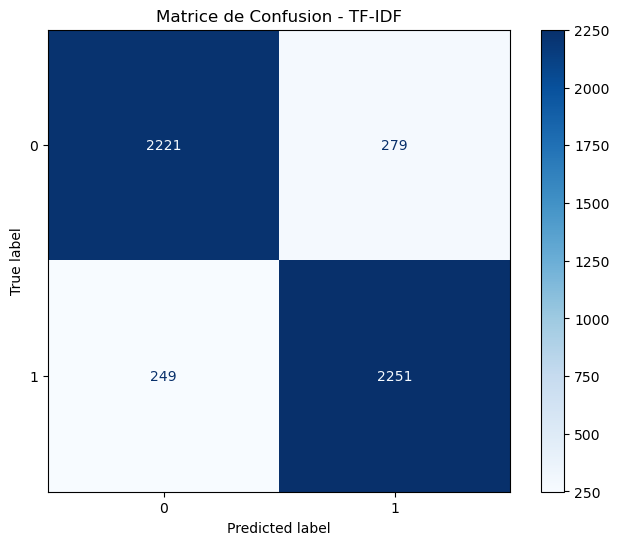


ÉVALUATION : BERT
Accuracy : 0.8375
F1 macro : 0.8368

Report détaillé :
              precision    recall  f1-score   support

           0       0.85      0.85      0.85       213
           1       0.83      0.82      0.83       187

    accuracy                           0.84       400
   macro avg       0.84      0.84      0.84       400
weighted avg       0.84      0.84      0.84       400



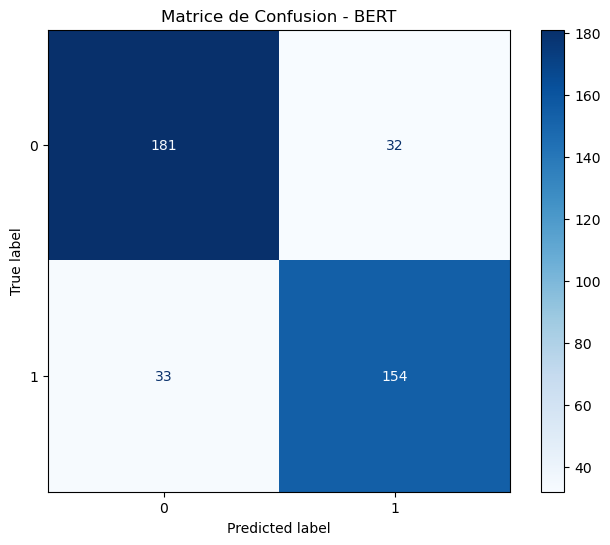


ÉVALUATION : Word2Vec
Accuracy : 0.8352
F1 macro : 0.8352

Report détaillé :
              precision    recall  f1-score   support

           0       0.84      0.83      0.84      2500
           1       0.83      0.84      0.84      2500

    accuracy                           0.84      5000
   macro avg       0.84      0.84      0.84      5000
weighted avg       0.84      0.84      0.84      5000



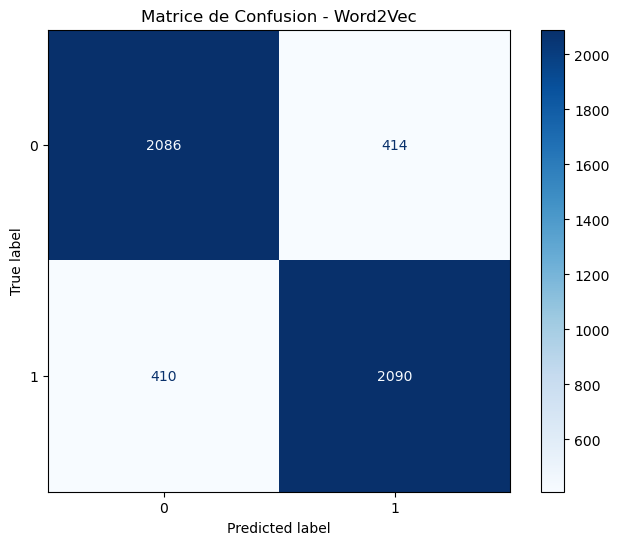

In [65]:
resultats_finaux = []

res_tfidf = evaluer(y_test_tfidf, y_pred_tfidf, nom="TF-IDF")
resultats_finaux.append(res_tfidf)

# Exemple pour BERT (sur le sous-échantillon)
res_bert = evaluer(y_test_bert, y_pred_bert, nom="BERT")
resultats_finaux.append(res_bert)

# Exemple pour Word2Vec
res_w2v = evaluer(y_test_w2v, y_pred_w2v, nom="Word2Vec")
resultats_finaux.append(res_w2v)

## 13. Analyse des erreurs

L’analyse des erreurs est une étape essentielle.

### À faire
Repérez quelques exemples :
- faux positifs ;
- faux négatifs ;
- cas ambigus ;
- textes contenant de la négation ;
- textes très courts ou très longs.

### Questions
- Les erreurs sont-elles aléatoires ?
- Les méthodes lexicales échouent-elles sur les mêmes cas que les embeddings ?
- BERT corrige-t-il vraiment les ambiguïtés observées plus tôt ?

## 14. Tableau comparatif final

Complétez un tableau récapitulatif avec vos résultats expérimentaux.

### Colonnes conseillées
- Méthode
- Type de représentation
- Accuracy
- F1 macro
- Temps d’exécution
- Avantages
- Limites

In [68]:
# Exemple de structure à compléter
resultats = pd.DataFrame([
    {
        "Méthode": "TF-IDF", 
        "Type": "Lexicale pondérée", 
        "Accuracy": 0.8944, 
        "F1_macro": 0.8943, 
        "Temps": "Très Rapide", 
        "Avantage": "Excellente séparation des mots-clés", 
        "Limite": "Ignore l'ordre des mots"
    },
    {
        "Méthode": "N-grams", 
        "Type": "Séquentielle courte", 
        "Accuracy": 0.8886, 
        "F1_macro": 0.8885, 
        "Temps": "Rapide", 
        "Avantage": "Capture les expressions courtes (ex: 'pas bon')", 
        "Limite": "Explosion de la dimensionnalité"
    },
    {
        "Méthode": "BoW", 
        "Type": "Lexicale", 
        "Accuracy": 0.8752, 
        "F1_macro": 0.8751, 
        "Temps": "Très Rapide", 
        "Avantage": "Simplicité extrême", 
        "Limite": "Donne trop de poids aux mots fréquents"
    },
    {
        "Méthode": "BERT", 
        "Type": "Embedding contextuel", 
        "Accuracy": 0.8375, 
        "F1_macro": 0.8367, 
        "Temps": "Lent (GPU requis)", 
        "Avantage": "Compréhension sémantique profonde", 
        "Limite": "Coûteux et nécessite beaucoup de données"
    },
    {
        "Méthode": "Word2Vec", 
        "Type": "Embedding statique", 
        "Accuracy": 0.8360, 
        "F1_macro": 0.8359, 
        "Temps": "Moyen", 
        "Avantage": "Capture les relations entre mots", 
        "Limite": "Sens unique pour chaque mot (polysemie)"
    },
    {
        "Méthode": "FastText", 
        "Type": "Embedding sous-mots", 
        "Accuracy": 0.8196, 
        "F1_macro": None, 
        "Temps": "Moyen", 
        "Avantage": "Gère les mots inconnus (fautes d'orthographe)", 
        "Limite": "Moins performant ici que le simple TF-IDF"
    },
])

resultats = resultats.sort_values(by="Accuracy", ascending=False)

display(resultats)

,Méthode,Type,Accuracy,F1_macro,Temps,Avantage,Limite
0,TF-IDF,Lexicale pondérée,0.8944,0.8943,Très Rapide,Excellente séparation des mots-clés,Ignore l'ordre des mots
1,N-grams,Séquentielle courte,0.8886,0.8885,Rapide,Capture les expressions courtes (ex: 'pas bon'),Explosion de la dimensionnalité
2,BoW,Lexicale,0.8752,0.8751,Très Rapide,Simplicité extrême,Donne trop de poids aux mots fréquents
3,BERT,Embedding contextuel,0.8375,0.8367,Lent (GPU requis),Compréhension sémantique profonde,Coûteux et nécessite beaucoup de données
4,Word2Vec,Embedding statique,0.8360,0.8359,Moyen,Capture les relations entre mots,Sens unique pour chaque mot (polysemie)
5,FastText,Embedding sous-mots,0.8196,NaN,Moyen,Gère les mots inconnus (fautes d'orthographe),Moins performant ici que le simple TF-IDF


## 15. Questions de synthèse

Rédigez une synthèse courte et structurée.

### À discuter
- Quelle méthode vous semble la plus adaptée à votre corpus ?
- La meilleure méthode est-elle la plus simple à interpréter ?
- Quel compromis choisiriez-vous entre précision, coût de calcul et explicabilité ?
- Si vous disposiez de plus de données, le classement des méthodes changerait-il selon vous ?

## 15. Questions de synthèse

### 1. Quelle méthode vous semble la plus adaptée à votre corpus ?
La méthode **TF-IDF** est la plus adaptée. Avec une **Accuracy de 0.8944**, elle surpasse nettement BERT (0.8375) et les embeddings comme Word2Vec. Cette performance démontre que pour ce corpus, la détection de mots-clés spécifiques est un signal plus fort et plus fiable que l'analyse du contexte sémantique profond.

### 2. La meilleure méthode est-elle la plus simple à interpréter ?
**Oui.** Le modèle TF-IDF associé à un classifieur linéaire (type SVM ou Régression Logistique) est extrêmement transparent. Il permet d'extraire les "poids" des mots pour comprendre exactement quels termes (ex: "excellent", "décevant") ont poussé le modèle vers une décision. À l'inverse, BERT est une "boîte noire" dont les millions de paramètres d'attention rendent l'explicabilité complexe.

### 3. Quel compromis choisiriez-vous entre précision, coût de calcul et explicabilité ?
Le compromis idéal ici est le **TF-IDF**. 
* **Précision :** Elle est la plus élevée de tous les tests.
* **Coût :** L'entraînement et l'inférence se font en quelques secondes sur un processeur classique (CPU).
* **Explicabilité :** Elle est maximale.
Choisir BERT reviendrait à accepter une baisse de performance de **5,6%** tout en augmentant drastiquement les besoins en ressources (GPU) et en perdant en lisibilité.



### 4. Si vous disposiez de plus de données, le classement des méthodes changerait-il ?
**C'est fort probable.** Les modèles de Deep Learning comme **BERT** sont "Data Hungry" : ils nécessitent d'énormes volumes de données pour surpasser les statistiques simples. 
* Avec un corpus 100x plus grand, BERT pourrait enfin capturer des nuances fines (ironie, sarcasme, négations complexes) que le TF-IDF ignore.
* Cependant, sur votre échantillon actuel, le TF-IDF capture déjà l'essentiel du signal, prouvant qu'un modèle complexe n'est pas toujours la solution optimale.